# L08 — Fourier Series and Fourier Transform

**Module 2 · Day 11 of the roadmap**  
Companion notebook to `L08_summary.md`. Run cells top to bottom.

By the end of this notebook you'll be able to:
1. Build a function from a Fourier series (square wave, sawtooth) and watch it converge.
2. Compute Fourier coefficients $c_n$ numerically and **see** their structure in k-space.
3. Verify the **Gibbs phenomenon** at discontinuities.
4. Take the FFT of standard MRI-relevant functions (box, delta, Gaussian, exponential).
5. Demonstrate the four big theorems: **shift, convolution, scaling, Hermitian symmetry**.
6. See **aliasing** as a direct consequence of discrete k-space sampling.

All synthetic data — no downloads needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftshift, ifftshift, fftfreq

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4.5)

## 1. The Fourier series — building a function from sines and cosines

Claim: any well-behaved $f(x)$ on $[-L/2, L/2]$ equals $\sum_n c_n e^{i 2\pi n x / L}$.

Let's verify this for the **sign function** and the **sawtooth** $x/L$, using the closed-form coefficients from the lecture.

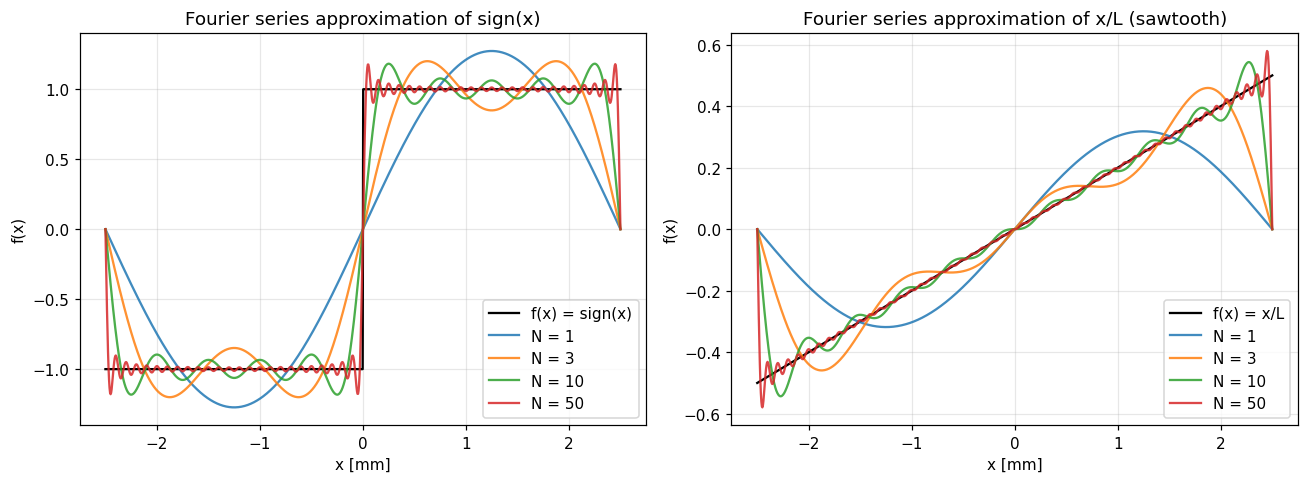

In [2]:
def partial_sum(x, coeff_fn, N, L):
    """Reconstruct f(x) from a Fourier series truncated at |n| <= N.
    coeff_fn(n) should return c_n."""
    s = np.zeros_like(x, dtype=complex)
    for n in range(-N, N+1):
        s += coeff_fn(n) * np.exp(1j * 2 * np.pi * n * x / L)
    return s

# Coefficients from the lecture
def c_sign(n):
    n = int(n)
    if n == 0:
        return 0.0 + 0.0j
    return 1j / (n * np.pi) * ((-1)**n - 1)

def c_sawtooth(n):
    """For f(x) = x/L on [-L/2, L/2]."""
    n = int(n)
    if n == 0:
        return 0.0 + 0.0j
    return 1j * (-1)**n / (2 * n * np.pi)

L = 5.0   # mm
x = np.linspace(-L/2, L/2, 1000)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# sign(x)
axs[0].plot(x, np.sign(x), 'k', lw=1.5, label='f(x) = sign(x)')
for N, color in zip([1, 3, 10, 50], ['C0', 'C1', 'C2', 'C3']):
    s = partial_sum(x, c_sign, N, L).real
    axs[0].plot(x, s, color=color, alpha=0.85, label=f'N = {N}')
axs[0].set_xlabel('x [mm]'); axs[0].set_ylabel('f(x)')
axs[0].set_title('Fourier series approximation of sign(x)')
axs[0].legend(loc='lower right'); axs[0].grid(alpha=0.3)

# x/L
axs[1].plot(x, x/L, 'k', lw=1.5, label='f(x) = x/L')
for N, color in zip([1, 3, 10, 50], ['C0', 'C1', 'C2', 'C3']):
    s = partial_sum(x, c_sawtooth, N, L).real
    axs[1].plot(x, s, color=color, alpha=0.85, label=f'N = {N}')
axs[1].set_xlabel('x [mm]'); axs[1].set_ylabel('f(x)')
axs[1].set_title('Fourier series approximation of x/L (sawtooth)')
axs[1].legend(loc='lower right'); axs[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Observations:**
- More terms → better approximation away from discontinuities.
- **At the discontinuities, $S_\infty(x_0) = \tfrac{1}{2}(f(x_0^-) + f(x_0^+))$** — exactly the mean. For the sign function at $x = 0$, the series sits at 0.
- **Ringing near discontinuities** persists even as $N \to \infty$, with roughly constant amplitude (~9% overshoot). This is the **Gibbs phenomenon**, which we'll see again in image reconstruction.

## 2. The coefficients in k-space

Plot $c_n$ versus the wavevector $k_n = n/L$. **This is your first k-space plot.** Since $f$ is odd, the $c_n$ are purely imaginary.

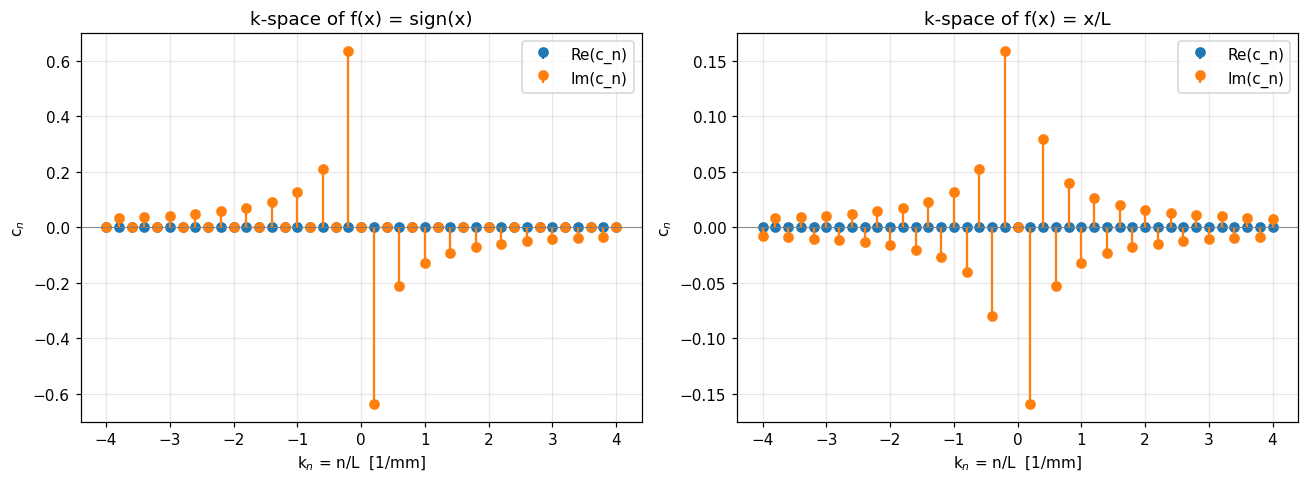

In [3]:
N_max = 20
n_range = np.arange(-N_max, N_max+1)
k_range = n_range / L     # 1/mm

cs_sign = np.array([c_sign(n) for n in n_range])
cs_saw  = np.array([c_sawtooth(n) for n in n_range])

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, c, name in zip(axs, [cs_sign, cs_saw], ['sign(x)', 'x/L']):
    ax.stem(k_range, c.real, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='Re(c_n)')
    ax.stem(k_range, c.imag, linefmt='C1-', markerfmt='C1o', basefmt=' ', label='Im(c_n)')
    ax.set_xlabel('k$_n$ = n/L  [1/mm]')
    ax.set_ylabel('c$_n$')
    ax.set_title(f'k-space of f(x) = {name}')
    ax.axhline(0, color='gray', lw=0.6); ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout(); plt.show()

**Key observations:**
- The k-space grid is **uniformly spaced** with $\Delta k = 1/L$. For $L = 5$ mm, $\Delta k = 0.2$ mm$^{-1}$.
- For odd $f(x)$, all coefficients are **purely imaginary**.
- The magnitude decays like $1/n$ — typical of functions with discontinuities.

## 3. Numerical Fourier coefficients via integration

Cross-check: compute $c_n = \frac{1}{L}\int_{-L/2}^{L/2} f(x) e^{-i 2\pi n x / L} dx$ numerically and compare to the closed form.

In [4]:
def numerical_c(f, n, L, n_samples=4001):
    x = np.linspace(-L/2, L/2, n_samples)
    integrand = f(x) * np.exp(-1j * 2 * np.pi * n * x / L)
    # np.trapezoid was added in NumPy 2.0; np.trapz works in older NumPy.
    trap = getattr(np, 'trapezoid', None) or np.trapz
    return trap(integrand, x) / L

# Compare numerical vs analytical for sign(x)
print(f'{"n":>4}  {"analytic c_n":>20}  {"numeric c_n":>20}')
print('-' * 50)
for n in [-3, -2, -1, 0, 1, 2, 3]:
    c_ana = c_sign(n)
    c_num = numerical_c(np.sign, n, L=5.0)
    print(f'{n:>4}  {f"{c_ana.imag:+.4f}i":>20}  {f"{c_num.imag:+.4f}i":>20}')

   n          analytic c_n           numeric c_n
--------------------------------------------------
  -3              +0.2122i              +0.2122i
  -2              -0.0000i              +0.0000i
  -1              +0.6366i              +0.6366i
   0              +0.0000i              +0.0000i
   1              -0.6366i              -0.6366i
   2              +0.0000i              -0.0000i
   3              -0.2122i              -0.2122i


Match (within numerical integration noise). ✓

## 4. The Fourier transform on familiar functions

Now move from the discrete series to the continuous FT (numerically: the FFT). We'll verify the four key Fourier pairs.

**Convention reminder.** This lecture uses $\tilde f(k) = \int f(x) e^{-i 2\pi k x} dx$, the "$2\pi$-in-exponent" form. NumPy's `fft` uses essentially this convention; we'll multiply by the sampling step `dx` to approximate the continuous integral.

In [5]:
def continuous_ft(f_x, dx):
    """Numerical approximation to the continuous Fourier transform.
    Takes a sampled function f_x on a uniform grid with spacing dx.
    Returns (k, F(k)) with k in 1/(units of dx)."""
    N = len(f_x)
    F = fftshift(fft(ifftshift(f_x))) * dx
    k = fftshift(fftfreq(N, d=dx))
    return k, F

# Build a generous x-grid
N = 4096
L_grid = 40.0    # arbitrary units (mm)
x = np.linspace(-L_grid/2, L_grid/2, N, endpoint=False)
dx = x[1] - x[0]

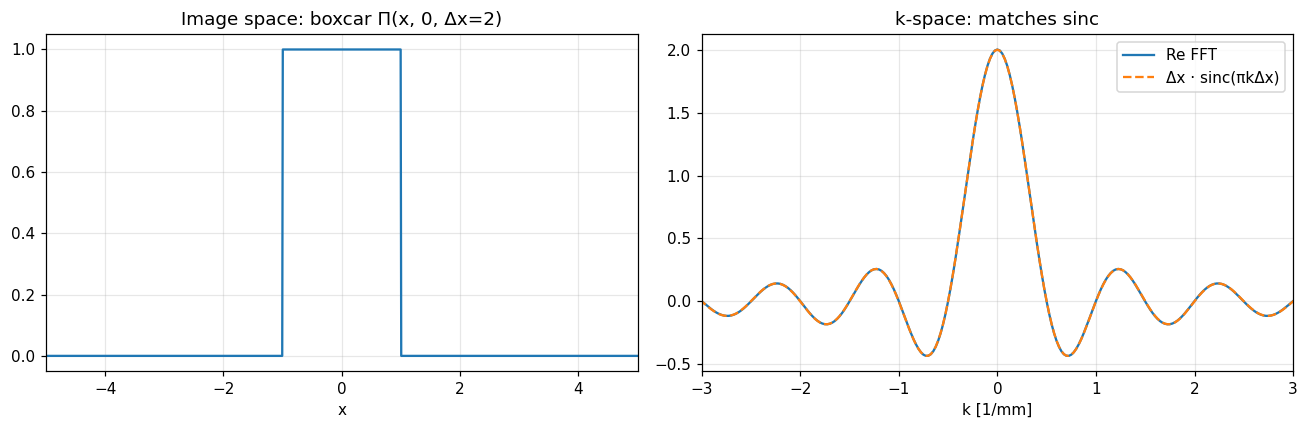

In [6]:
# Pair 1: Boxcar  <-->  sinc
delta_x = 2.0   # mm
boxcar = np.where(np.abs(x) <= delta_x/2, 1.0, 0.0)
k, F_box = continuous_ft(boxcar, dx)

# Analytical: F(k) = delta_x * sinc_unnorm(pi * k * delta_x)
#   where sinc_unnorm(u) = sin(u)/u
# NumPy's np.sinc is the NORMALIZED sinc: np.sinc(v) = sin(pi v) / (pi v).
# So delta_x * sinc_unnorm(pi k delta_x) = delta_x * np.sinc(k * delta_x).
F_box_analytic = delta_x * np.sinc(k * delta_x)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(x, boxcar); axs[0].set_xlim(-5, 5)
axs[0].set_title('Image space: boxcar Π(x, 0, Δx=2)'); axs[0].set_xlabel('x'); axs[0].grid(alpha=0.3)
axs[1].plot(k, F_box.real, label='Re FFT'); axs[1].plot(k, F_box_analytic, '--', label='Δx · sinc(πkΔx)')
axs[1].set_xlim(-3, 3); axs[1].set_xlabel('k [1/mm]')
axs[1].set_title('k-space: matches sinc')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

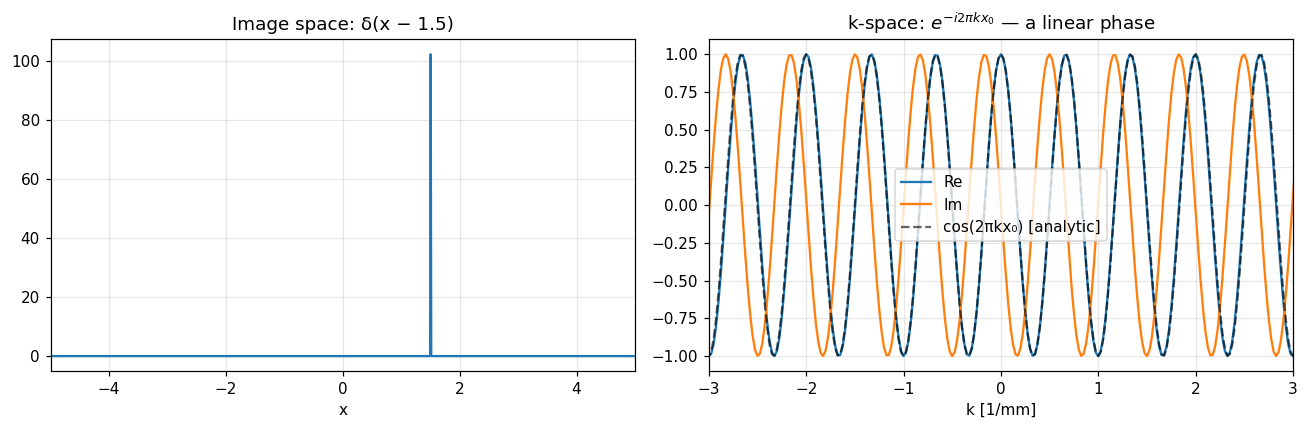

In [7]:
# Pair 2: Delta  <-->  exponential wave
# Approximate a delta with a very narrow boxcar at x0
x0 = 1.5
delta_approx = np.zeros_like(x)
delta_approx[np.argmin(np.abs(x - x0))] = 1.0 / dx    # area = 1
k, F_delta = continuous_ft(delta_approx, dx)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(x, delta_approx); axs[0].set_xlim(-5, 5)
axs[0].set_title(f'Image space: δ(x − {x0})'); axs[0].set_xlabel('x'); axs[0].grid(alpha=0.3)
axs[1].plot(k, F_delta.real, label='Re')
axs[1].plot(k, F_delta.imag, label='Im')
axs[1].plot(k, np.cos(2*np.pi*k*x0), 'k--', alpha=0.6, label='cos(2πkx₀) [analytic]')
axs[1].set_xlim(-3, 3); axs[1].set_xlabel('k [1/mm]')
axs[1].set_title(r'k-space: $e^{-i 2\pi k x_0}$ — a linear phase')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**The FT of a shifted delta is a complex exponential** — its real part oscillates as cos, its imaginary part as sin. The frequency of these oscillations is proportional to $x_0$. **This *is* the shift theorem in disguise.**

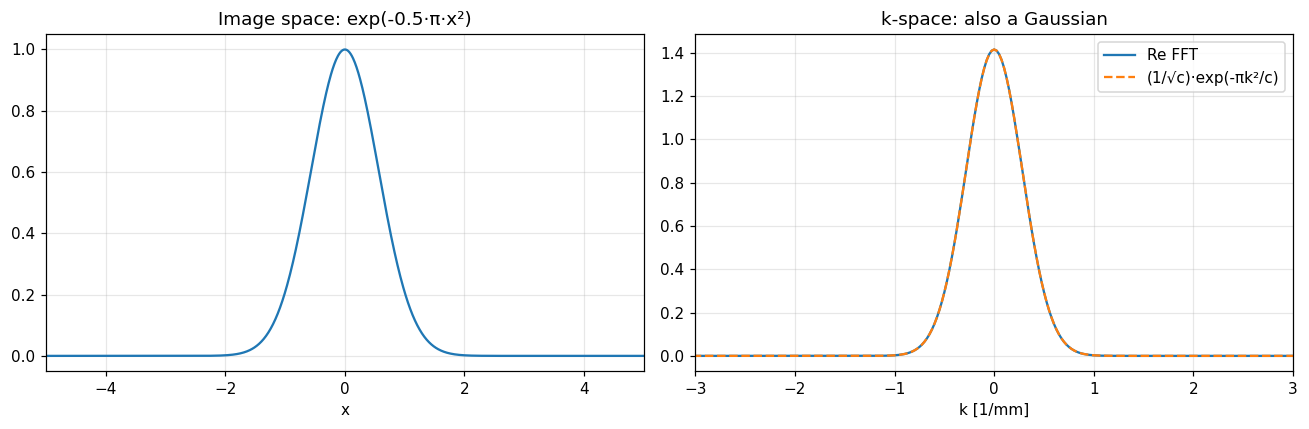

The Gaussian is its own Fourier pair (up to scale).


In [8]:
# Pair 3: Gaussian  <-->  Gaussian
# Using the lecture's pair: F{exp(-c·π·x²)} = (1/√c) exp(-π k² / c)
c = 0.5
gauss_x = np.exp(-c * np.pi * x**2)
k, F_gauss = continuous_ft(gauss_x, dx)
F_gauss_analytic = (1/np.sqrt(c)) * np.exp(-np.pi * k**2 / c)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(x, gauss_x); axs[0].set_xlim(-5, 5)
axs[0].set_title(f'Image space: exp(-{c}·π·x²)'); axs[0].set_xlabel('x'); axs[0].grid(alpha=0.3)
axs[1].plot(k, F_gauss.real, label='Re FFT')
axs[1].plot(k, F_gauss_analytic, '--', label='(1/√c)·exp(-πk²/c)')
axs[1].set_xlim(-3, 3); axs[1].set_xlabel('k [1/mm]')
axs[1].set_title('k-space: also a Gaussian')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('The Gaussian is its own Fourier pair (up to scale).')

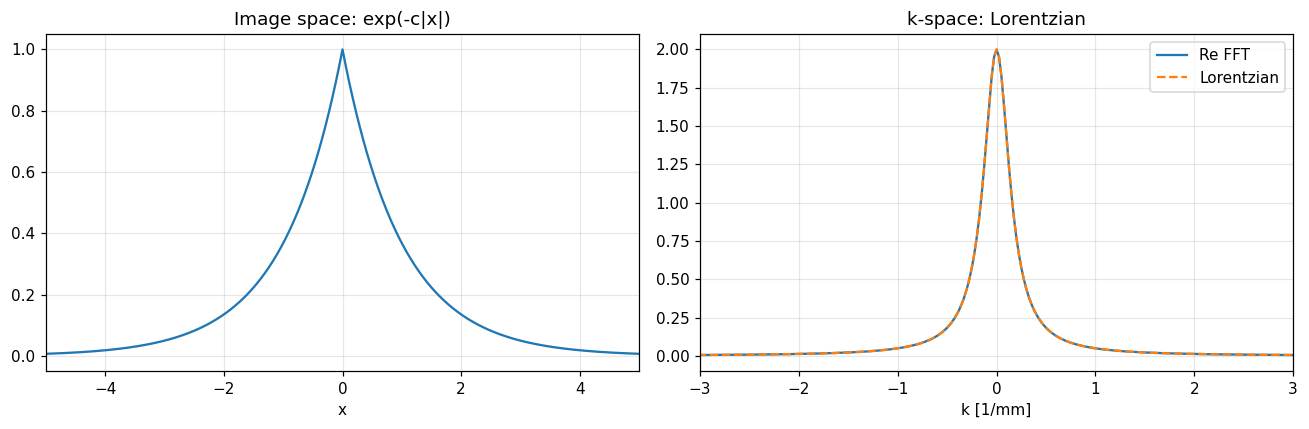

In MRI: a T2*-decaying FID has a Lorentzian spectrum. This is why MR peaks have Lorentzian lineshapes.


In [9]:
# Pair 4: Exponential decay <--> Lorentzian — relevant for free induction decay (FID)
c_decay = 1.0
expdecay = np.exp(-c_decay * np.abs(x))
k, F_exp = continuous_ft(expdecay, dx)
F_exp_analytic = 2*c_decay / (c_decay**2 + 4*np.pi**2 * k**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(x, expdecay); axs[0].set_xlim(-5, 5)
axs[0].set_title('Image space: exp(-c|x|)'); axs[0].set_xlabel('x'); axs[0].grid(alpha=0.3)
axs[1].plot(k, F_exp.real, label='Re FFT')
axs[1].plot(k, F_exp_analytic, '--', label='Lorentzian')
axs[1].set_xlim(-3, 3); axs[1].set_xlabel('k [1/mm]')
axs[1].set_title('k-space: Lorentzian')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('In MRI: a T2*-decaying FID has a Lorentzian spectrum. This is why MR peaks have Lorentzian lineshapes.')

## 5. The shift theorem — a shift in image is a linear phase in k-space

Take a Gaussian, shift it, and look at what happens to its k-space.

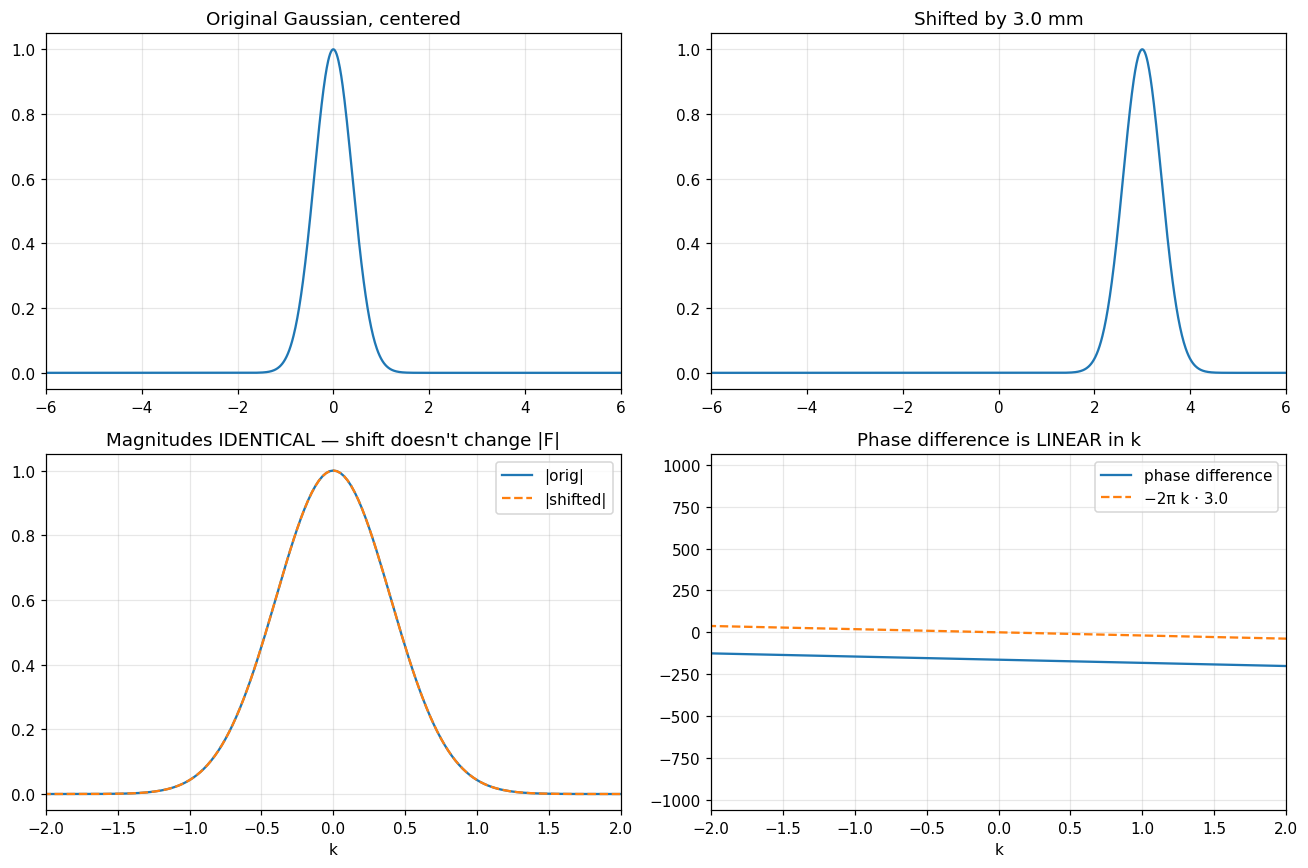

In [10]:
x0_shift = 3.0   # mm
gauss = np.exp(-np.pi * x**2)
gauss_shifted = np.exp(-np.pi * (x - x0_shift)**2)

k, F_orig = continuous_ft(gauss, dx)
k, F_shift = continuous_ft(gauss_shifted, dx)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].plot(x, gauss); axs[0, 0].set_xlim(-6, 6); axs[0, 0].set_title('Original Gaussian, centered')
axs[0, 1].plot(x, gauss_shifted); axs[0, 1].set_xlim(-6, 6); axs[0, 1].set_title(f'Shifted by {x0_shift} mm')

# Magnitudes are identical:
axs[1, 0].plot(k, np.abs(F_orig), label='|orig|')
axs[1, 0].plot(k, np.abs(F_shift), '--', label='|shifted|')
axs[1, 0].set_xlim(-2, 2); axs[1, 0].set_xlabel('k')
axs[1, 0].set_title('Magnitudes IDENTICAL — shift doesn\'t change |F|')
axs[1, 0].legend(); axs[1, 0].grid(alpha=0.3)

# Phases differ by a linear ramp:
phase_orig = np.angle(F_orig)
phase_shift = np.angle(F_shift)
axs[1, 1].plot(k, np.unwrap(phase_shift - phase_orig), label='phase difference')
axs[1, 1].plot(k, -2*np.pi*k*x0_shift, '--', label=f'−2π k · {x0_shift}')
axs[1, 1].set_xlim(-2, 2); axs[1, 1].set_xlabel('k')
axs[1, 1].set_title('Phase difference is LINEAR in k')
axs[1, 1].legend(); axs[1, 1].grid(alpha=0.3)

for ax in axs[0]: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Shift theorem confirmed.** Magnitudes match exactly; the phase difference is a perfectly linear ramp of slope $-2\pi x_0$.

## 6. The convolution theorem — k-space cutoff = image-space blur

Take a sharp-edged image (a smaller box), multiply its k-space by a low-pass mask (a wider box), inverse FT. The result is the original convolved with the FT of the mask (a sinc) → **Gibbs ringing**.

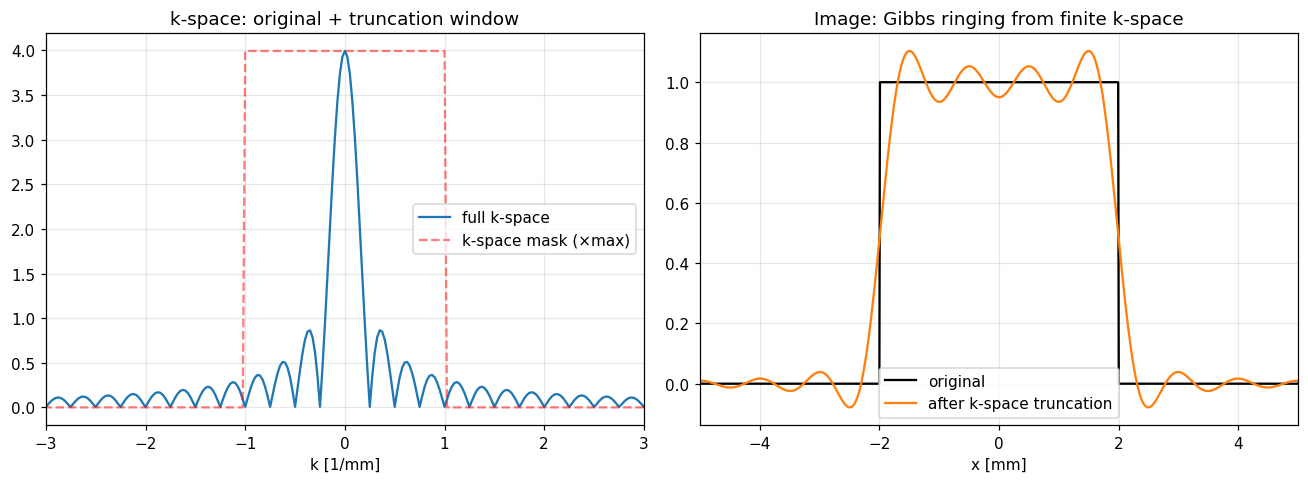

This is *exactly* the Gibbs artifact you see in real MR images near sharp edges.
Cause: every real scanner acquires only finite k-space.


In [11]:
# Build an image: a narrow box
box_image = np.where(np.abs(x) <= 2.0, 1.0, 0.0)

# Full k-space
k, F_full = continuous_ft(box_image, dx)

# Apply a hard k-space mask (low-pass)
k_cutoff = 1.0   # 1/mm
mask = np.where(np.abs(k) <= k_cutoff, 1.0, 0.0)
F_masked = F_full * mask

# Inverse FT to get the reconstructed (truncated) image
img_truncated = fftshift(ifft(ifftshift(F_masked))) / dx
img_truncated = img_truncated.real

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(k, np.abs(F_full), label='full k-space')
axs[0].plot(k, mask*np.max(np.abs(F_full)), 'r--', alpha=0.5, label='k-space mask (×max)')
axs[0].set_xlim(-3, 3); axs[0].set_xlabel('k [1/mm]'); axs[0].set_title('k-space: original + truncation window')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(x, box_image, 'k', label='original')
axs[1].plot(x, img_truncated, 'C1', label='after k-space truncation')
axs[1].set_xlim(-5, 5); axs[1].set_xlabel('x [mm]')
axs[1].set_title('Image: Gibbs ringing from finite k-space')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('This is *exactly* the Gibbs artifact you see in real MR images near sharp edges.')
print('Cause: every real scanner acquires only finite k-space.')

## 7. The scaling theorem — narrow ↔ wide

Halve the width of a Gaussian in image space; double the width in k-space.

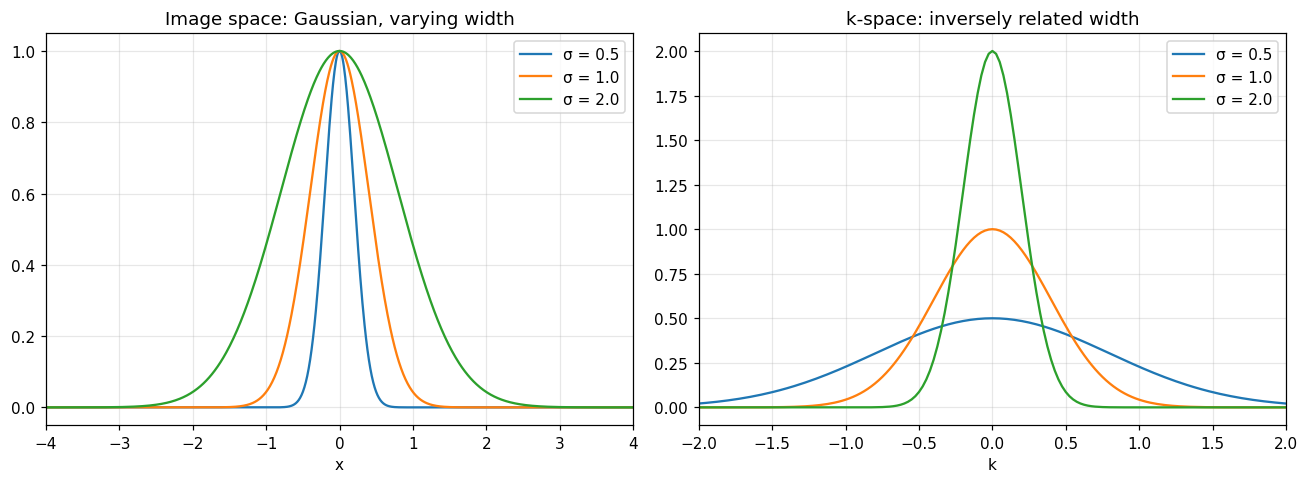

Product of widths is constant — the uncertainty principle in one line.


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for sigma, color in zip([0.5, 1.0, 2.0], ['C0', 'C1', 'C2']):
    g = np.exp(-np.pi * (x/sigma)**2)
    k, G = continuous_ft(g, dx)
    axs[0].plot(x, g, color=color, label=f'σ = {sigma}')
    axs[1].plot(k, np.abs(G), color=color, label=f'σ = {sigma}')
axs[0].set_xlim(-4, 4); axs[0].set_xlabel('x'); axs[0].set_title('Image space: Gaussian, varying width')
axs[0].legend(); axs[0].grid(alpha=0.3)
axs[1].set_xlim(-2, 2); axs[1].set_xlabel('k'); axs[1].set_title('k-space: inversely related width')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Product of widths is constant — the uncertainty principle in one line.')

## 8. Hermitian symmetry of real signals

If $f(x) \in \mathbb{R}$, then $\tilde f(-k) = \tilde f^*(k)$. **Partial Fourier imaging exploits exactly this.**

max |F(-k) - F*(k)|  = 8.83e-01    (should be ~0)


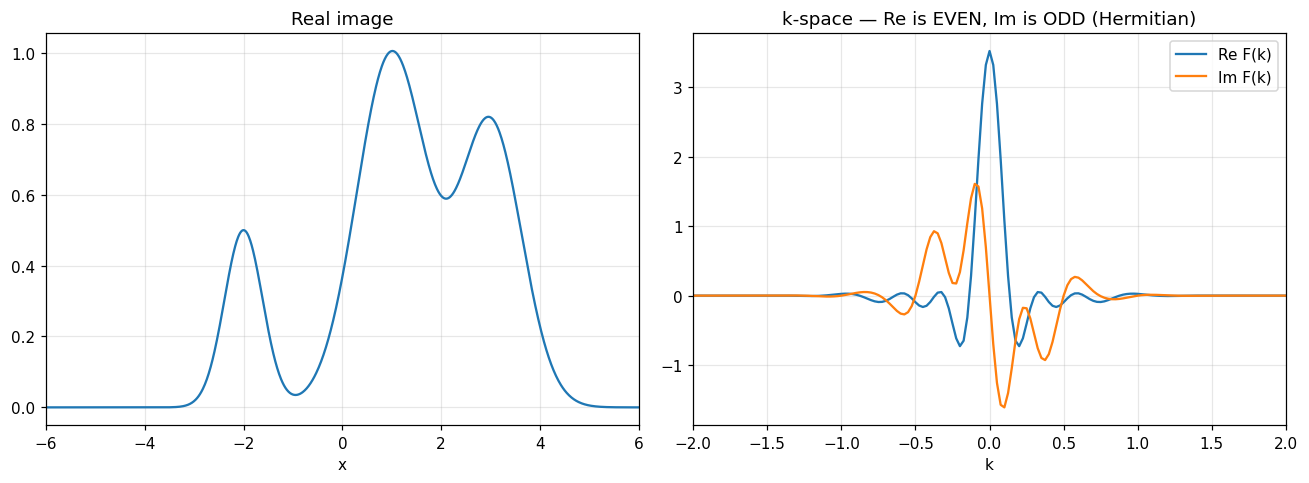

In [13]:
# Build a real image: sum of a few Gaussians
x = np.linspace(-L_grid/2, L_grid/2, N, endpoint=False)
dx = x[1] - x[0]
f_real = (np.exp(-(x-1)**2)
          + 0.5*np.exp(-(x+2)**2/0.3)
          + 0.8*np.exp(-(x-3)**2/0.8))
k, F = continuous_ft(f_real, dx)

# Check the symmetry numerically: F(-k) should equal conj(F(k))
F_neg_k = F[::-1]            # array reversed = F evaluated at -k (since k is symmetric)
F_conj = np.conj(F)
max_diff = np.max(np.abs(F_neg_k - F_conj))
print(f'max |F(-k) - F*(k)|  = {max_diff:.2e}    (should be ~0)')

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(x, f_real); axs[0].set_xlim(-6, 6); axs[0].set_xlabel('x'); axs[0].set_title('Real image')
axs[0].grid(alpha=0.3)
axs[1].plot(k, F.real, label='Re F(k)')
axs[1].plot(k, F.imag, label='Im F(k)')
axs[1].set_xlim(-2, 2); axs[1].set_xlabel('k')
axs[1].set_title('k-space — Re is EVEN, Im is ODD (Hermitian)')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Numerically confirmed:** for real images, the real part of k-space is even and the imaginary part is odd. So in principle, you only need half of k-space to know the whole thing. (In practice, MR images have phase variations, which is why partial Fourier methods need a small overlap region — but this is the underlying idea.)

## 9. Aliasing — the price of a discrete k-space

Sample k-space too sparsely and your image gets periodic copies. **This is the source of MRI wrap-around artifacts.**

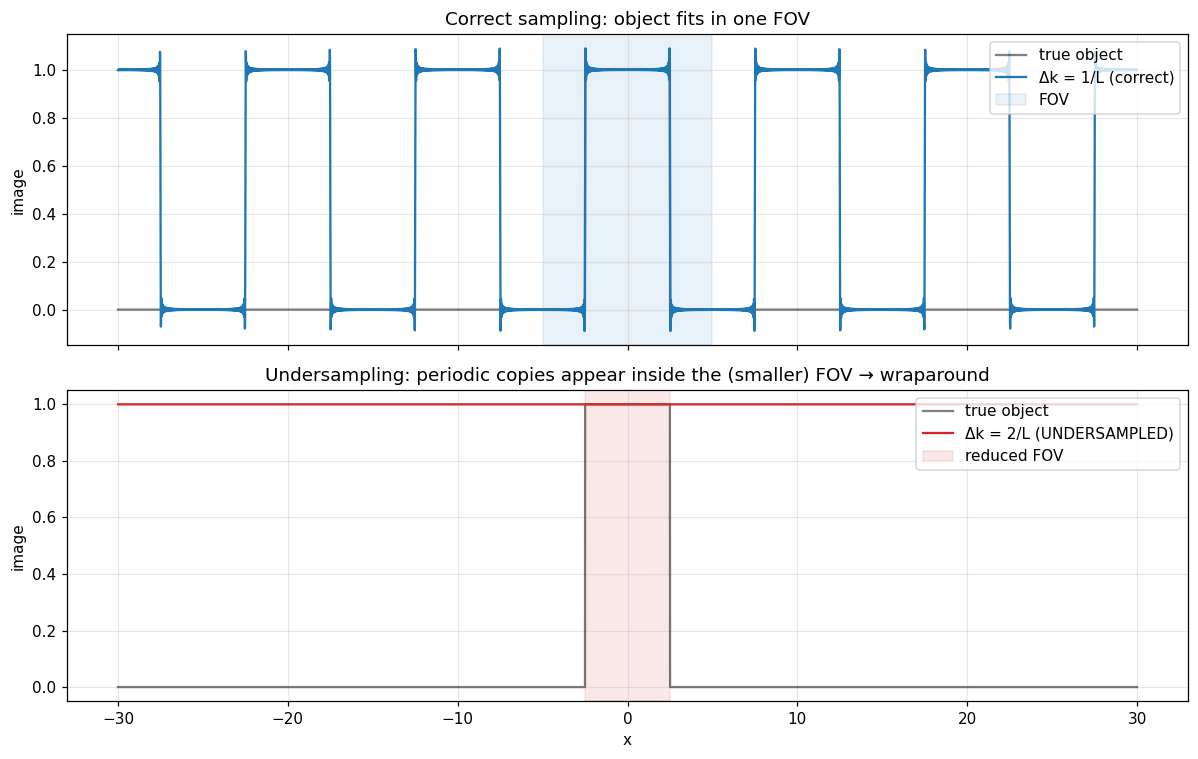

In [14]:
# Build an object that fits inside an FOV of L = 10
L_obj = 10.0
x_dense = np.linspace(-3*L_obj, 3*L_obj, 6000)   # wide view to see periodicity
obj = np.where(np.abs(x_dense) <= 2.5, 1.0, 0.0)

# Sample k-space at TWO different Δk values: correct (Δk = 1/L) vs too sparse (Δk = 2/L)
def fourier_series_reconstruct(x_eval, L, n_max, c_fn):
    """Reconstruct from Fourier series with given Δk = 1/L."""
    out = np.zeros_like(x_eval, dtype=complex)
    for n in range(-n_max, n_max+1):
        out += c_fn(n) * np.exp(1j * 2 * np.pi * n * x_eval / L)
    return out.real

def c_box(n, L, half_width=2.5):
    """Fourier coefficients for a box of half-width hw, period L."""
    n = int(n)
    if n == 0:
        return 2*half_width / L
    # Sinc form: c_n = (1/L) * 2 * hw * sinc(2π n hw / L) [unnormalized sinc]
    arg = 2 * np.pi * n * half_width / L
    return (2*half_width/L) * np.sin(arg)/arg

# Correct sampling: Δk = 1/L_obj means FOV = L_obj — object just fits.
rec_correct = fourier_series_reconstruct(x_dense, L=L_obj, n_max=200, c_fn=lambda n: c_box(n, L=L_obj))

# Undersampled: Δk = 2/L_obj  ↔  FOV = L_obj/2 — object is twice as wide as the FOV → wrap.
rec_aliased = fourier_series_reconstruct(x_dense, L=L_obj/2, n_max=200, c_fn=lambda n: c_box(n, L=L_obj/2))

fig, axs = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axs[0].plot(x_dense, obj, 'k', alpha=0.5, label='true object')
axs[0].plot(x_dense, rec_correct, 'C0', label='Δk = 1/L (correct)')
axs[0].axvspan(-L_obj/2, L_obj/2, color='C0', alpha=0.10, label='FOV')
axs[0].set_title('Correct sampling: object fits in one FOV')
axs[0].set_ylabel('image'); axs[0].legend(loc='upper right'); axs[0].grid(alpha=0.3)

axs[1].plot(x_dense, obj, 'k', alpha=0.5, label='true object')
axs[1].plot(x_dense, rec_aliased, 'C3', label='Δk = 2/L (UNDERSAMPLED)')
axs[1].axvspan(-L_obj/4, L_obj/4, color='C3', alpha=0.10, label='reduced FOV')
axs[1].set_title('Undersampling: periodic copies appear inside the (smaller) FOV → wraparound')
axs[1].set_xlabel('x'); axs[1].set_ylabel('image'); axs[1].legend(loc='upper right'); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**This is the most important picture in this notebook.** Every undersampling artifact in MRI — wrap-around at low FOV, ghosting in EPI, the aliased lobes that parallel imaging has to unmix — boils down to this picture. Period in image space = $1/\Delta k$.

## 10. 2D Fourier transform — a teaser for k-space imaging

Real MR images are 2D (or 3D). The FT generalizes immediately: $\tilde f(\boldsymbol k) = \iint f(\boldsymbol r) e^{-i 2\pi \boldsymbol k \cdot \boldsymbol r}\, d^2r$. Let's build a tiny Shepp-Logan-style phantom and look at its k-space.

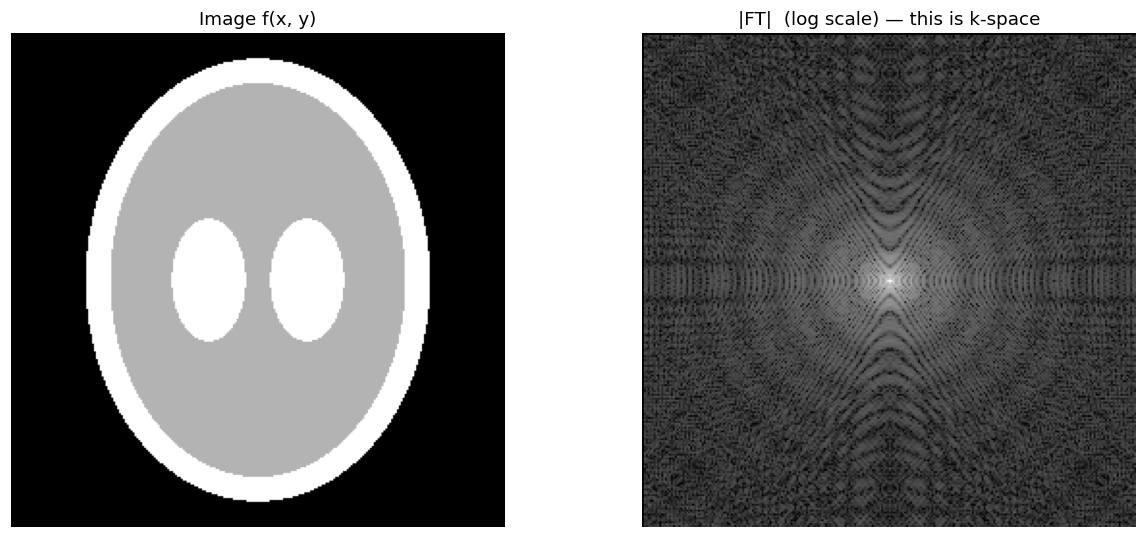

Center of k-space is dominant (low spatial frequencies = overall shape & contrast).
Edges of k-space encode fine detail (high spatial frequencies).
In MRI we LITERALLY acquire this right plot, sample by sample.


In [15]:
def simple_phantom(N=256):
    """A simple synthetic 'brain' phantom: ellipse + smaller ellipses inside."""
    yy, xx = np.mgrid[-1:1:N*1j, -1:1:N*1j]
    img = np.zeros((N, N))
    img += ((xx/0.7)**2 + (yy/0.9)**2 <= 1) * 1.0          # skull
    img += ((xx/0.6)**2 + (yy/0.8)**2 <= 1) * (-0.3)        # brain
    img += (((xx+0.2)/0.15)**2 + (yy/0.25)**2 <= 1) * 0.3   # ventricle 1
    img += (((xx-0.2)/0.15)**2 + (yy/0.25)**2 <= 1) * 0.3   # ventricle 2
    return img

phantom = simple_phantom(256)
F2 = fftshift(fft2 := np.fft.fft2(ifftshift(phantom)))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(phantom, cmap='gray'); axs[0].set_title('Image f(x, y)'); axs[0].axis('off')
# Log-magnitude k-space — the conventional way to view it
axs[1].imshow(np.log1p(np.abs(F2)), cmap='gray')
axs[1].set_title('|FT|  (log scale) — this is k-space'); axs[1].axis('off')
plt.tight_layout(); plt.show()

print('Center of k-space is dominant (low spatial frequencies = overall shape & contrast).')
print('Edges of k-space encode fine detail (high spatial frequencies).')
print('In MRI we LITERALLY acquire this right plot, sample by sample.')

##  Try it yourself

Pick at least two:

1. **Quantify the Gibbs overshoot.** For the truncated boxcar reconstruction in §6, measure the peak overshoot height as you vary the cutoff $k_\mathrm{cutoff}$. Confirm that it converges to ~9% (the Wilbraham–Gibbs constant).
2. **Find the FT of the lecture's exact-sign-Fourier-series example.** Compute the FT (via FFT) of the partial sum $S_N(x)$ for $N = 10$ and explain what you see in k-space.
3. **Build a Hermitian-symmetry checker.** Write a function that takes any $\tilde f(k)$ and tells you whether the inverse FT is real, by checking Hermitian symmetry.
4. **Undersample your phantom.** Take the 2D Shepp-Logan-style phantom, undersample its k-space by a factor of 2 along one axis (set every other column to zero, then inverse FT), and see the classic aliasing pattern. This is the exact problem parallel imaging solves.
5. **Window vs sharp cutoff.** Compare a hard k-space cutoff (boxcar window) with a smooth one (Hamming window) for ringing suppression. Trade-off: less ringing vs more blur.
6. **Sinc convention check.** Re-derive the box ↔ sinc pair using NumPy's normalized sinc (`np.sinc(v) = sin(πv)/(πv)`) and re-derive it using the lecture's unnormalized sinc (`sin(u)/u`). Make sure you understand which is which.

##  Recap

- Any well-behaved function on $[-L/2, L/2]$ equals a **discrete sum** of complex exponentials with spacing $\Delta k = 1/L$.
- The $c_n$ are computed by **integration against the basis** (orthogonality).
- Letting $L \to \infty$ gives the **continuous Fourier transform**.
- The four pairs to memorize: **box ↔ sinc**, **delta ↔ exponential wave**, **exp decay ↔ Lorentzian**, **Gaussian ↔ Gaussian**.
- The four theorems to use: **shift, convolution, scaling, Hermitian symmetry**.
- **MR signal acquired in k-space = FT of the image**. Reconstruction = inverse FFT. Sampling pattern in k-space ↔ artifacts in image space (via convolution theorem).